In [20]:
import os
import pandas as pd
from utils.feature_extraction import extract_tree_features
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

folder_path = 'data/train_data'

all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.laz')]

with ProcessPoolExecutor() as executor:
    features = list(tqdm(executor.map(extract_tree_features, all_files), total = len(all_files)))

results = [f for f in features if f is not None]

df = pd.DataFrame(results)

100%|██████████| 17707/17707 [05:21<00:00, 55.06it/s] 


In [23]:
print(df.head)

<bound method NDFrame.head of         filename  point_density  top_heavy  num_points  height  \
0      00070.laz    4216.922827   0.758912       79260   9.018   
1      00071.laz    4245.450156   0.735794       88461   7.841   
2      00072.laz    3337.002363   0.472811       68132  14.895   
3      00073.laz    1388.721273   0.692420      522001  18.734   
4      00074.laz    5126.381633   0.720822       22199   6.497   
...          ...            ...        ...         ...     ...   
17702  20241.laz     116.452149   0.754446       14457  11.120   
17703  20242.laz     144.843094   0.782469       12528  13.040   
17704  20243.laz      77.002367   0.715491       10874  16.260   
17705  20244.laz      77.704049   0.705400       10176  14.020   
17706  20246.laz     107.456858   0.733662        9171  15.140   

       crown_diameter  crown_area  crown_ratio      volume  dbh_approx  \
0               2.884    5.307031     0.588493   18.795696      0.1035   
1               3.711    6.97

In [24]:
from sklearn.model_selection import train_test_split

labels_df = pd.read_csv("data/train_data/labels.csv")                

print(f"Features (from laz): {len(df)}")
print(f"Labels (from csv):   {len(labels_df)}")

df['join_id'] = df['filename'].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

labels_df['join_id'] = labels_df['filename'].apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)

full_data = pd.merge(df, labels_df, on='join_id', how='inner')

print(f"Matched Trees: {len(full_data)}")

#juste pour vérifier que les données matchent bien
full_data['height_diff'] = abs(full_data['height'] - full_data['tree_H'])
print(f"Avg Height Diff: {full_data['height_diff'].mean():.2f}m")

clean_data = full_data.copy()
print(f"Trees after cleaning bad matches: {len(clean_data)}")

train_df, val_df = train_test_split(
    clean_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=clean_data['species']
)

cols_to_keep = [
    'crown_ratio','height', 'point_density','top_heavy','crown_ratio','volume', 'crown_area', 'num_points', 'crown_diameter', 'point_density', 'dbh_approx', 'p10_height_rel', 'p50_height_rel', 'p90_height_rel',
    'species', 'genus'
]

Features (from laz): 17707
Labels (from csv):   17707
Matched Trees: 17707
Avg Height Diff: 0.00m
Trees after cleaning bad matches: 17707


In [32]:
feature_cols = [
    'height', 'dbh_approx',
    'p10_height_rel',
    'top_heavy', 'crown_ratio' 
]

Entrainement complet

Model Accuracy: 55.05%
------------------------------
Classification Report:
                       precision    recall  f1-score   support

           Abies_alba       0.57      0.33      0.42        24
       Acer_campestre       0.33      0.45      0.38       248
  Acer_pseudoplatanus       0.45      0.52      0.48       115
       Acer_saccharum       0.38      0.23      0.29        22
       Betula_pendula       0.43      0.24      0.31       147
     Carpinus_betulus       0.27      0.19      0.23       249
     Corylus_avellana       0.40      0.22      0.29         9
   Crataegus_monogyna       0.12      0.09      0.10        46
   Eucalyptus_miniata       0.65      0.70      0.67        56
   Euonymus_europaeus       0.00      0.00      0.00        21
      Fagus_sylvatica       0.49      0.63      0.55       496
Fraxinus_angustifolia       0.71      0.24      0.36        21
   Fraxinus_excelsior       0.00      0.00      0.00        25
        Larix_deci

c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

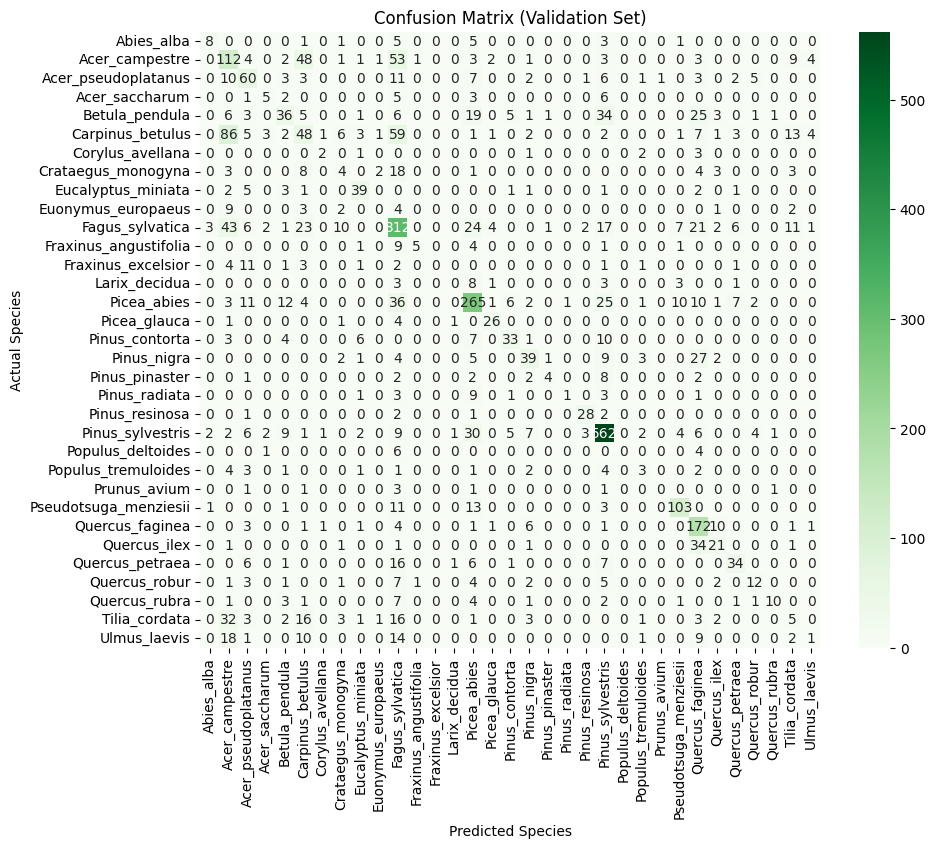

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



target_col = 'species'

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train_encoded)

print("Entrainement complet")

y_pred = rf_model.predict(X_val)
accuracy = accuracy_score(y_val_encoded, y_pred)

print(f"\nModel Accuracy: {accuracy:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred, target_names=le.classes_))

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

In [31]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Setup
X = train_df[feature_cols]
y = y_train_encoded

# 2. Define the "Selector"
# n_features_to_select=5 means "Keep only the top 5 best features"
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=5)

# 3. Fit (This takes a moment, it trains the model multiple times)
print("Finding the best features...")
rfe.fit(X, y)

# 4. See results
ranking = pd.DataFrame({'Feature': feature_cols, 'Rank': rfe.ranking_, 'Keep': rfe.support_})
print(ranking.sort_values(by='Rank'))

# The features with Rank 1 are your "Super Features". 
# You can retrain your model using ONLY those.

Finding the best features...
           Feature  Rank   Keep
0           height     1   True
7   p10_height_rel     1   True
6       dbh_approx     1   True
5    point_density     1   True
11     crown_ratio     1   True
3       num_points     2  False
9   p90_height_rel     3  False
1           volume     4  False
10       top_heavy     5  False
4   crown_diameter     6  False
8   p50_height_rel     7  False
2       crown_area     8  False
